
Running inference on device: cuda
Loading model from: ../networks/model.pt
[INFO] Dataset loaded with 50000 signals (normalize=True)
[INFO] Normalization stats - Mean: 25.5307, Std: 22.0381
[INFO] Train set: 37500 | Val set: 7500 | Test set: 5000
Loaded batch: 32 signals
Predictions - pos: (32, 1024), heights: (32, 3), widths: (32, 3)


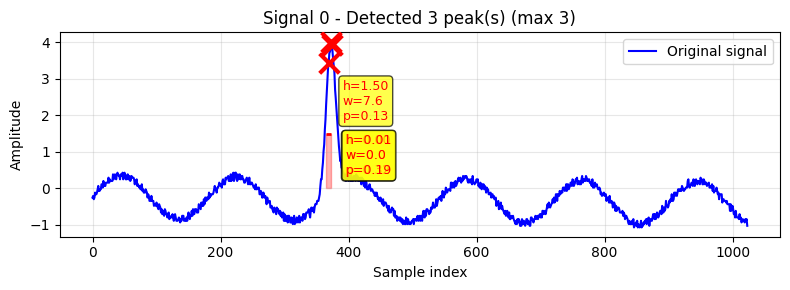

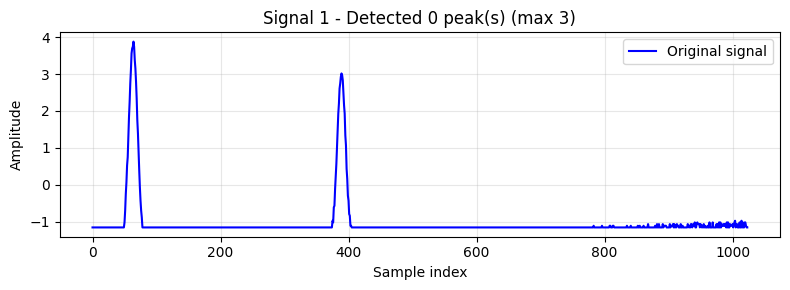

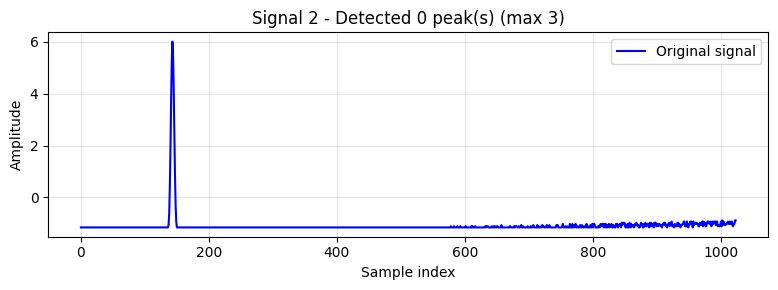

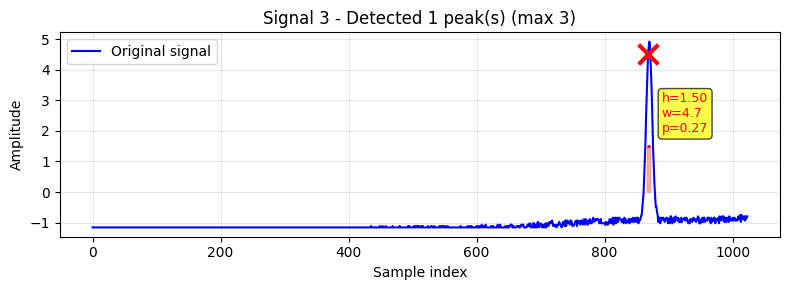

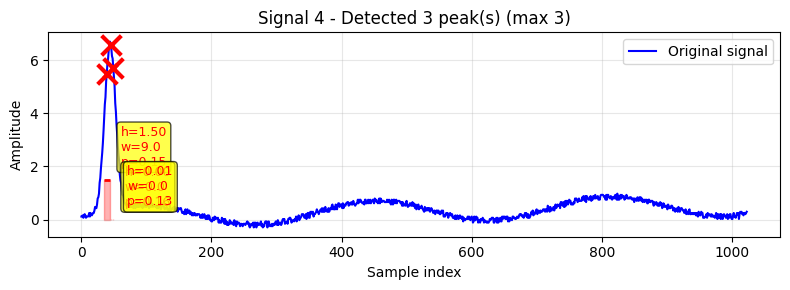

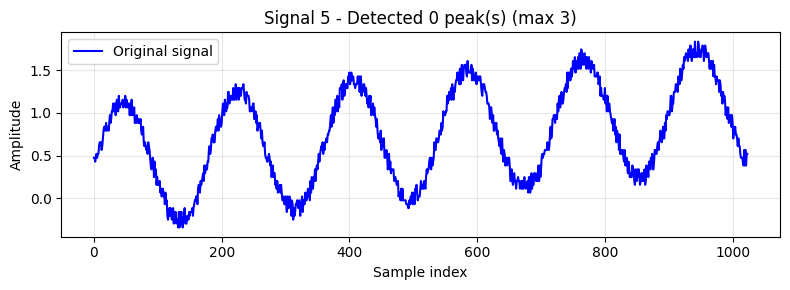

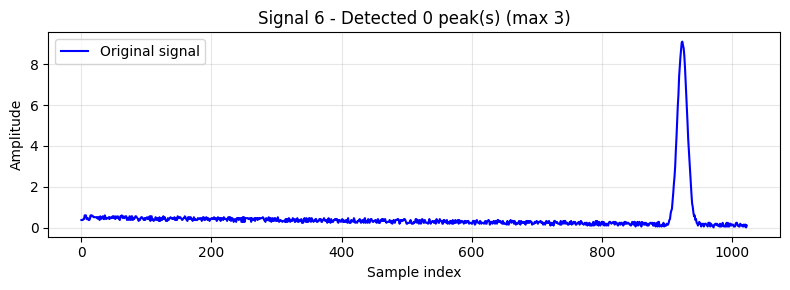

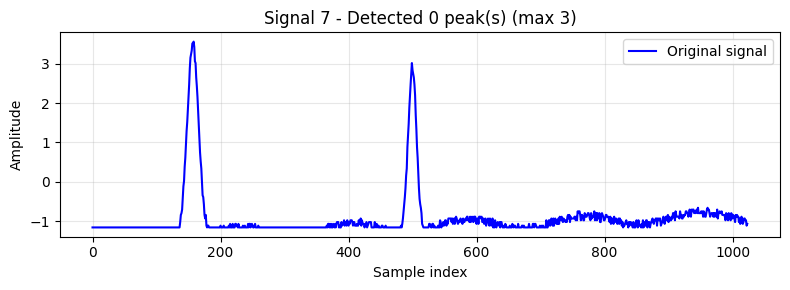

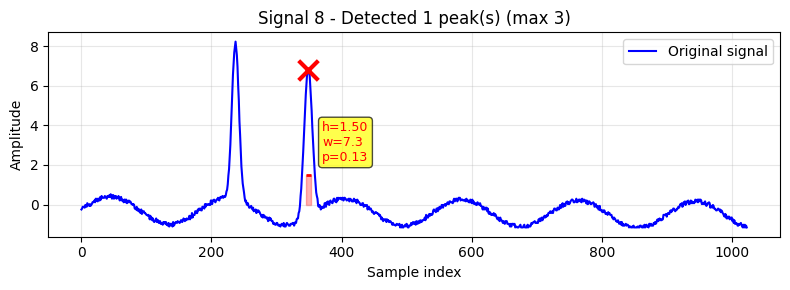

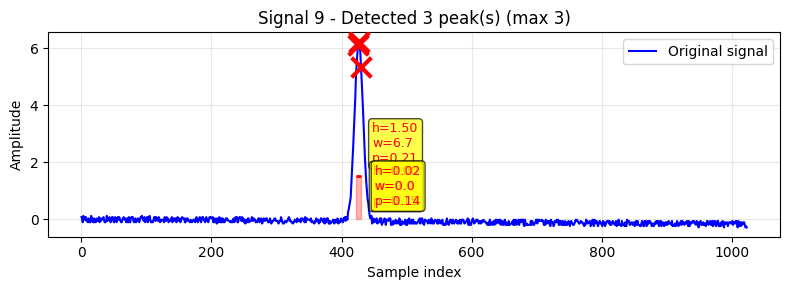

In [85]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# Add project root to path
project_root = os.path.abspath('..') 
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from networks.PeakDetectionModel import PeakDetectionModel
from run import prepare_dataset

# -------------------- HARD-CODED PARAMETERS --------------------
signal_path = "../data/signal.raw"
info_path = "../data/info.raw"
chunks = 1024
max_peaks = 3
batch_size = 32
shuffle = True
train_split = 0.75
val_split = 0.15
normalize = True 
seed = 42  

# -------------------- CONFIGURATION --------------------
model_path = "../networks/model.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Create a config object with all needed attributes
class Config:
    signal_path = signal_path
    info_path = info_path
    chunks = chunks
    max_peaks = max_peaks
    batch_size = batch_size
    shuffle = shuffle
    train_split = train_split
    val_split = val_split
    normalize = normalize 
    seed = seed 
    device = device

args = Config()
print(f"\nRunning inference on device: {device}")
print(f"Loading model from: {model_path}")

# -------------------- DATASET --------------------
_, _, test_loader = prepare_dataset(args)

# -------------------- MODEL --------------------
model = PeakDetectionModel(signal_length=chunks, max_peaks=max_peaks)
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

# -------------------- INFERENCE ON FIRST BATCH --------------------
with torch.no_grad():
    for signals, true_pos, true_height, true_width in test_loader:
        signals = signals.to(device)
        pred_pos, pred_heights, pred_widths = model(signals.unsqueeze(1))
        
        pred_pos = pred_pos.detach().cpu().numpy()
        pred_heights = pred_heights.detach().cpu().numpy()
        pred_widths = pred_widths.detach().cpu().numpy()
        break 

print(f"Loaded batch: {signals.shape[0]} signals")
print(f"Predictions - pos: {pred_pos.shape}, heights: {pred_heights.shape}, widths: {pred_widths.shape}")

# -------------------- VISUALIZATION: TOP 3 PEAKS --------------------
for i in range(min(10, signals.shape[0])):  # Ridotto a 10 per non sovraccaricare
    signal_example = signals[i].cpu().numpy()
    positions_pred = pred_pos[i]    
    heights_pred = pred_heights[i]
    widths_pred = pred_widths[i]
    
    plt.figure(figsize=(8, 3))
    plt.plot(signal_example, label="Original signal", linewidth=1.5, color='blue')
    
    threshold = 0.1
    peak_indices = np.where(positions_pred > threshold)[0]
    peak_probs = positions_pred[peak_indices]
    
    # Keep only top-3 peaks with highest probability
    if len(peak_indices) > 3:
        top_3_idx = np.argsort(peak_probs)[-3:]
        peak_indices = peak_indices[top_3_idx]
        peak_probs = peak_probs[top_3_idx]
    
    # Ordina per posizione
    sort_idx = np.argsort(peak_indices)
    peak_indices = peak_indices[sort_idx]
    peak_probs = peak_probs[sort_idx]
    
    num_peaks = len(peak_indices)
    
    if num_peaks > 0:
        # Disegna rettangoli colorati per altezza e larghezza
        for idx in range(num_peaks):
            pos = peak_indices[idx]
            height = heights_pred[idx]
            width = widths_pred[idx]
            
            start = pos - width / 2
            stop = pos + width / 2
            
            # Rettangolo colorato
            plt.fill_between([start, stop], 0, height, 
                           alpha=0.3, color='red')
            
            # Linea orizzontale per l'altezza
            plt.hlines(height, start, stop, colors='red', linewidth=2)
            
            # Marker sulla posizione del picco
            plt.scatter([pos], [signal_example[int(pos)]], 
                       s=200, color='red', marker='x', linewidths=3, zorder=5)
            
            # Annotazione
            plt.annotate(f'h={height:.2f}\nw={width:.1f}\np={peak_probs[idx]:.2f}', 
                        xy=(pos, height),
                        xytext=(10, 10), textcoords='offset points',
                        fontsize=9, color='red',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    plt.title(f"Signal {i} - Detected {num_peaks} peak(s) (max 3)")
    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [67]:
import sys
import os

project_root = os.path.abspath('..') 
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from networks.PeakDetectionModel import PeakDetectionModel
from run import prepare_dataset

In [68]:
# -------------------- HARD-CODED PARAMETERS --------------------
signal_path = "../data/signal.raw"
info_path = "../data/info.raw"
chunks = 1024
max_peaks = 3
batch_size = 32
shuffle = True
train_split = 0.75
val_split = 0.15
normalize = True 
seed = 42  

# -------------------- CONFIGURATION --------------------
model_path = "../networks/model.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Create a config object with all needed attributes
class Config:
    signal_path = signal_path
    info_path = info_path
    chunks = chunks
    max_peaks = max_peaks
    batch_size = batch_size
    shuffle = shuffle
    train_split = train_split
    val_split = val_split
    normalize = normalize 
    seed = seed 
    device = device

args = Config()
print(f"\nRunning inference on device: {device}")
print(f"Loading model from: {model_path}")


Running inference on device: cuda
Loading model from: ../networks/model.pt


In [69]:
#-------------------- DATASET --------------------
_, _, test_loader = prepare_dataset(args)

[INFO] Dataset loaded with 50000 signals (normalize=True)
[INFO] Normalization stats - Mean: 25.5307, Std: 22.0381
[INFO] Train set: 37500 | Val set: 7500 | Test set: 5000


In [70]:
# -------------------- MODEL --------------------
model = PeakDetectionModel(signal_length=chunks)
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

PeakDetectionModel(
  (net): Sequential(
    (0): Conv1d(1, 32, kernel_size=(15,), stride=(1,))
    (1): ReLU()
    (2): Conv1d(32, 64, kernel_size=(15,), stride=(1,))
    (3): ReLU()
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=31872, out_features=2048, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (fc_positions): Linear(in_features=2048, out_features=1024, bias=True)
  (fc_heights): Linear(in_features=2048, out_features=3, bias=True)
  (fc_width): Linear(in_features=2048, out_features=3, bias=True)
  (sigmoid): Sigmoid()
)

In [71]:
# -------------------- INFERENCE --------------------
all_predictions = []
with torch.no_grad():
    for i, (signal, _, _, _) in enumerate(test_loader):
        signal = signal.to(device)
        pred_pos, pred_height, pred_width = model(signal.unsqueeze(1))

        preds = {
            "positions": pred_pos.cpu().numpy(),
            "heights": pred_height.cpu().numpy(),
            "widths": pred_width.cpu().numpy()
        }
        all_predictions.append(preds)

        if i % 10 == 0:
            print(f"Batch {i}: positions {pred_pos.shape}, heights {pred_height.shape}, widths {pred_width.shape}")


Batch 0: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 10: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 20: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 30: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 40: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 50: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 60: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 70: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 80: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
Batch 90: positions torch.Size([32, 1024]), heights torch.Size([32, 3]), widths torch.Size([32, 3])
B

In [72]:

# Print some information
print("Predicted positions (shape):", all_predictions[0]["positions"].shape)
print("Predicted heights (shape):", all_predictions[0]["heights"].shape)
print("Predicted widths (shape):", all_predictions[0]["widths"].shape)

# If you want to see the first 10 values of each prediction
print("\nFirst 10 predicted positions:", all_predictions[0]["positions"][0][:])
print("First 10 predicted heights:", all_predictions[0]["heights"][0][:10])
print("First 10 predicted widths:", all_predictions[0]["widths"][0][:10])


Predicted positions (shape): (32, 1024)
Predicted heights (shape): (32, 3)
Predicted widths (shape): (32, 3)

First 10 predicted positions: [6.6554011e-13 3.9770409e-13 5.3181548e-13 ... 6.9119211e-13 2.9557620e-13
 1.5065057e-13]
First 10 predicted heights: [1.5        0.00335178 0.01416866]
First 10 predicted widths: [7.6081367 0.        0.       ]


In [73]:
all_predictions[0]["positions"][0][:]


array([6.6554011e-13, 3.9770409e-13, 5.3181548e-13, ..., 6.9119211e-13,
       2.9557620e-13, 1.5065057e-13], shape=(1024,), dtype=float32)

In [74]:
# -------------------- FIRST BATCH AND INFERENCE --------------------
with torch.no_grad():
    for signals, true_pos, true_height, true_width in test_loader:
        signals = signals.to(device)
        pred_pos, pred_heights, pred_widths = model(signals.unsqueeze(1))
        
        pred_pos = pred_pos.detach().cpu().numpy()
        pred_heights = pred_heights.detach().cpu().numpy()
        pred_widths = pred_widths.detach().cpu().numpy()
        break 


In [75]:
signals.shape[0]


32

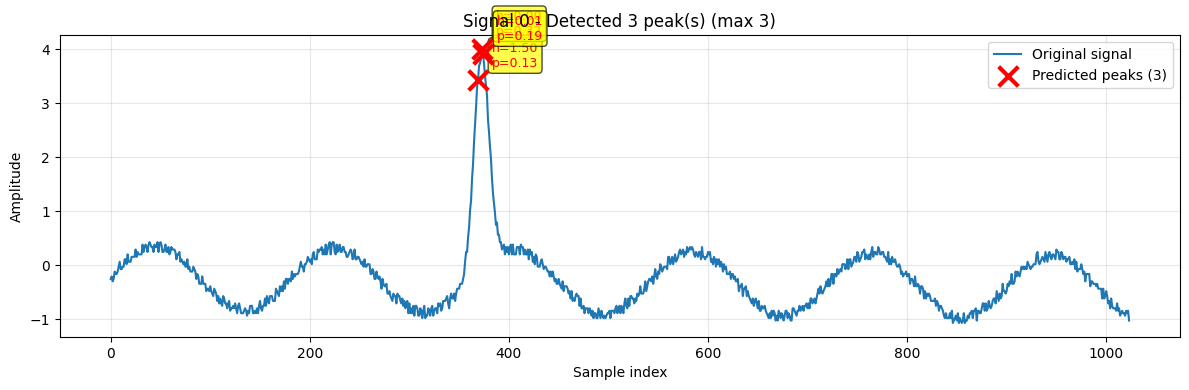

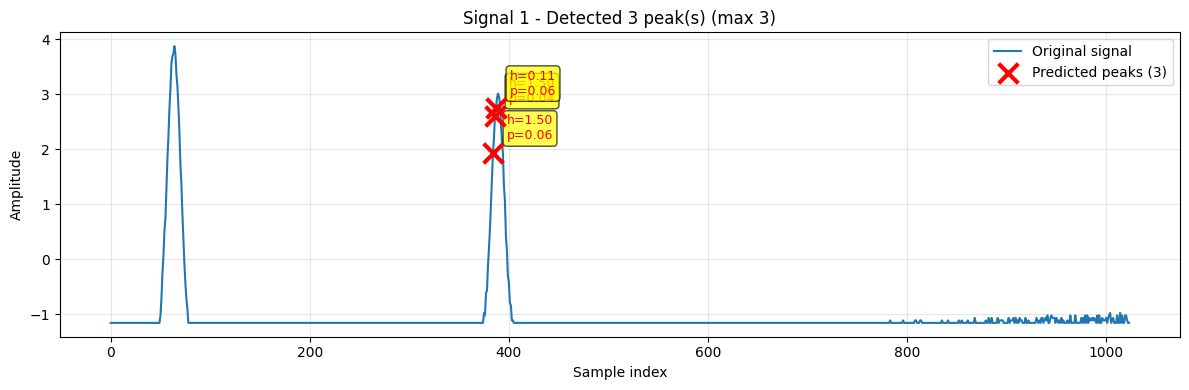

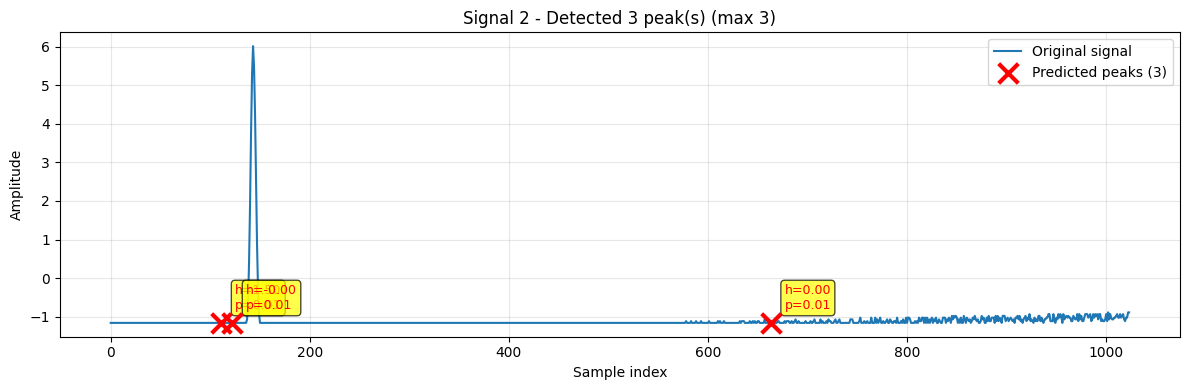

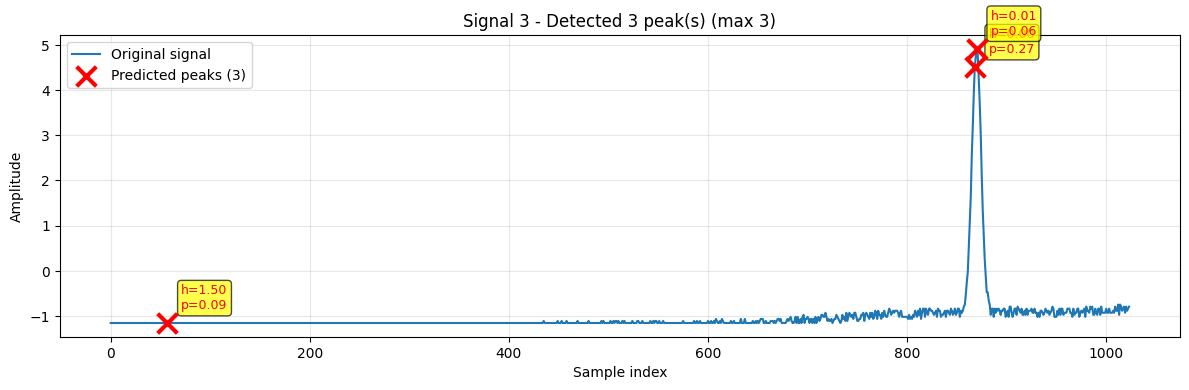

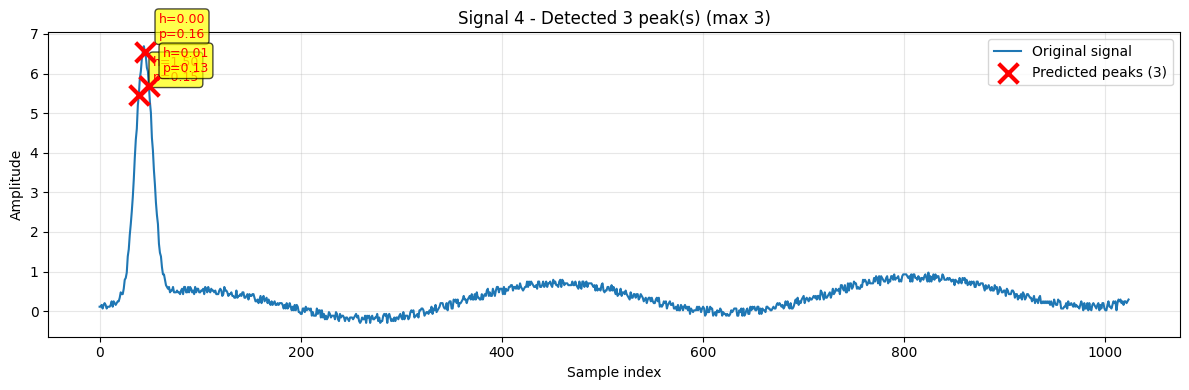

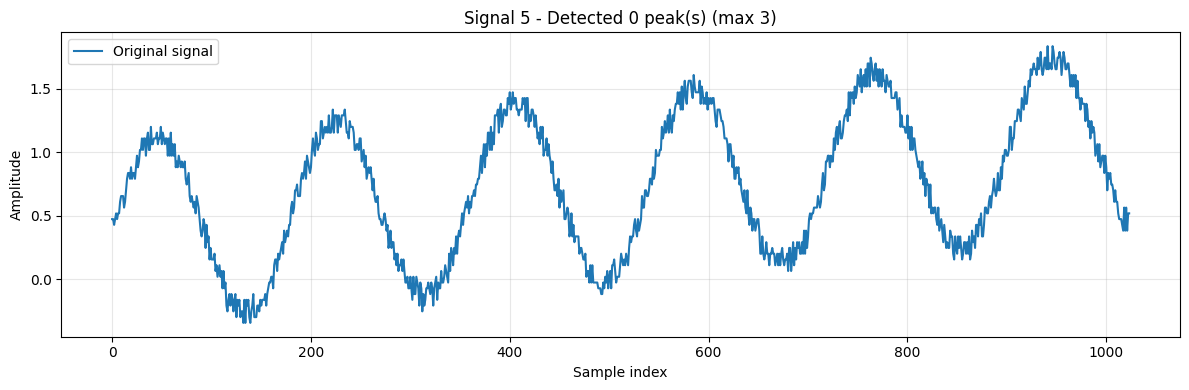

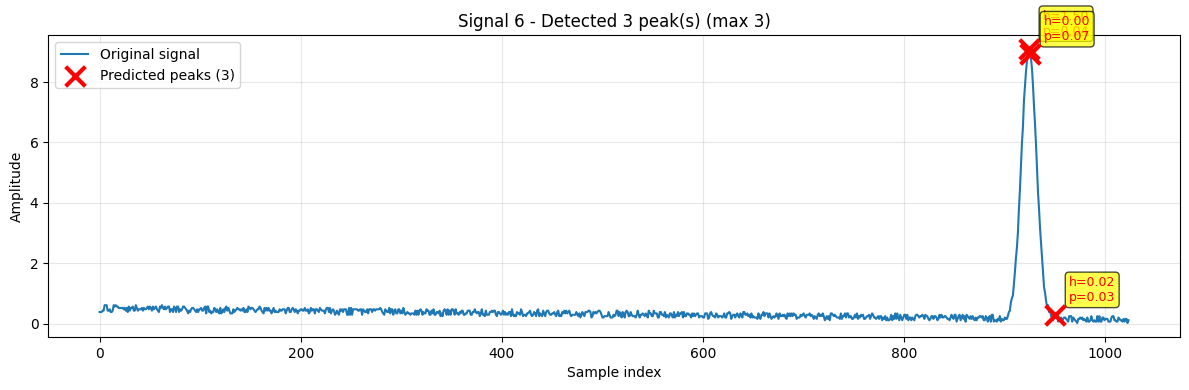

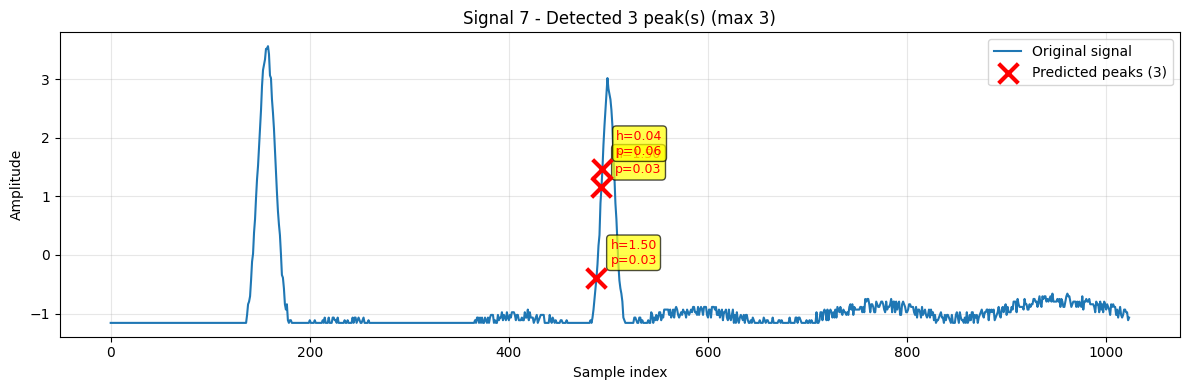

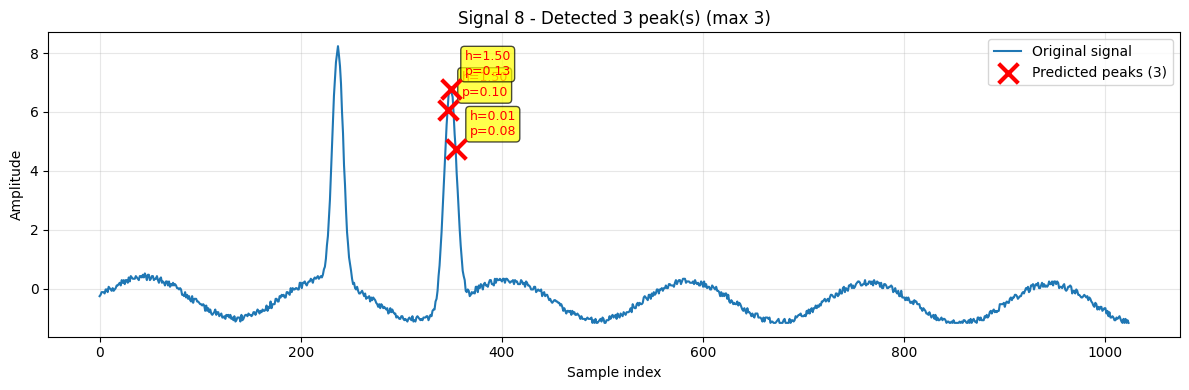

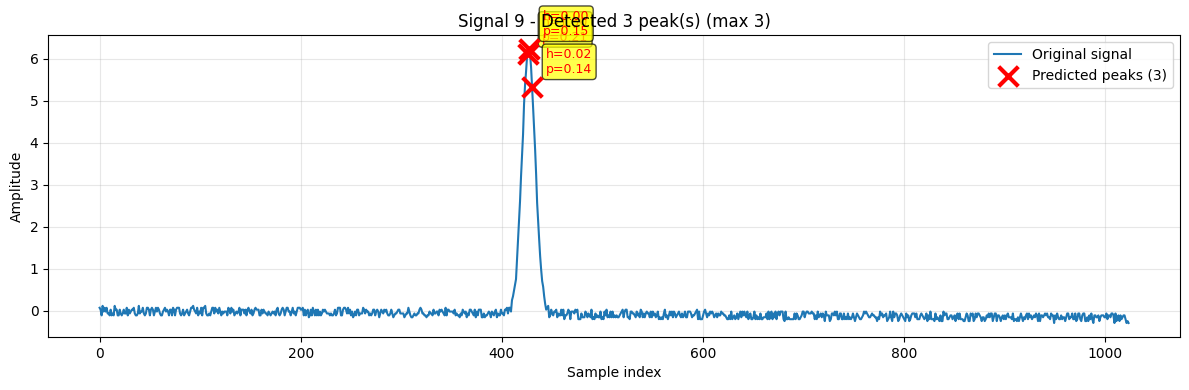

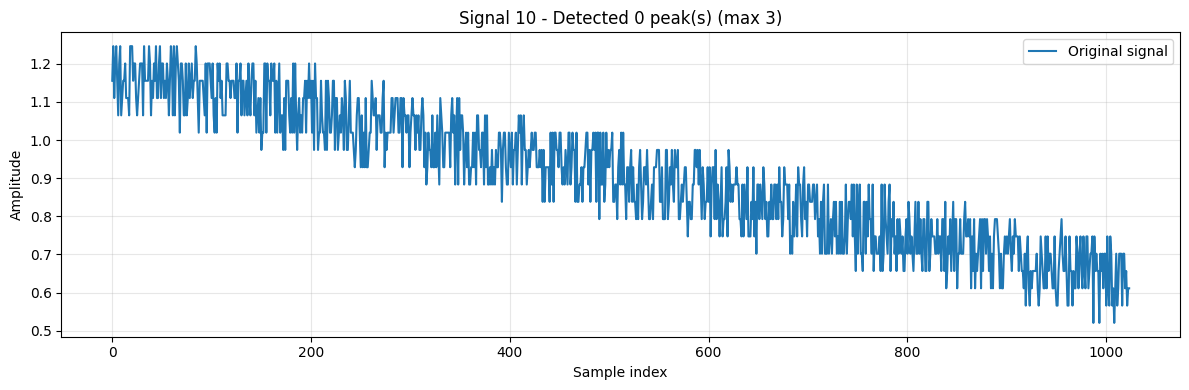

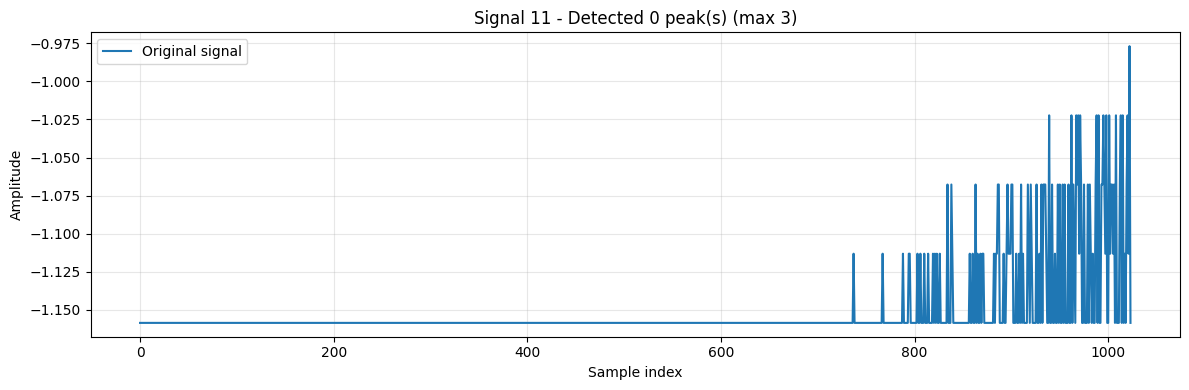

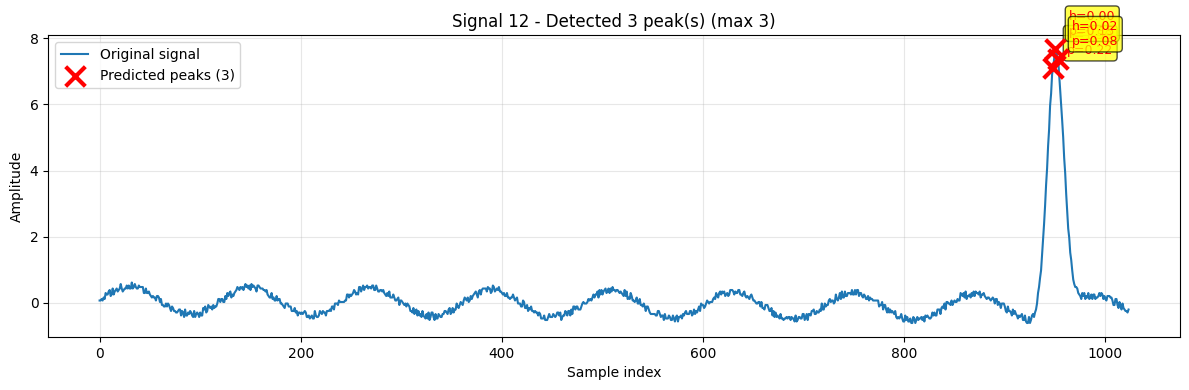

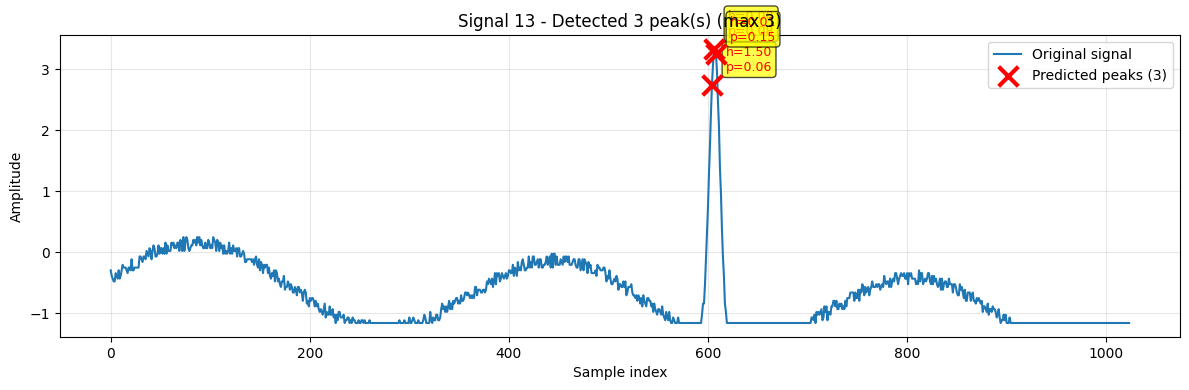

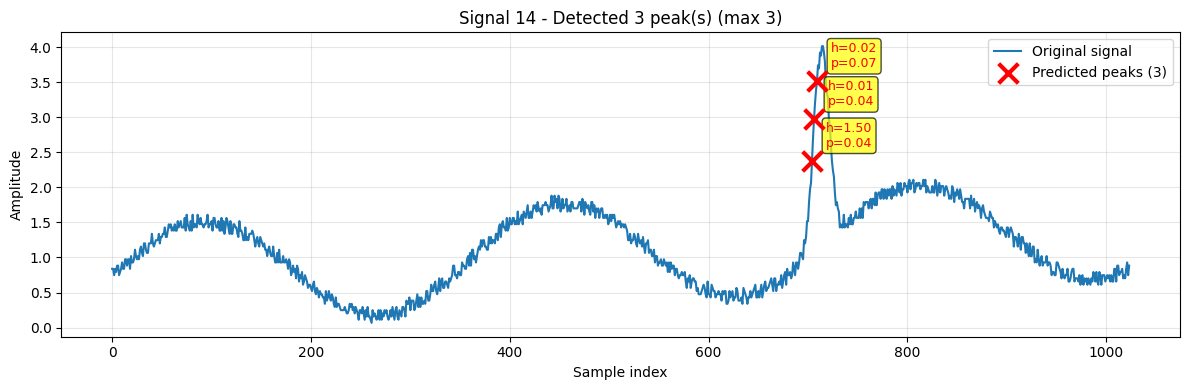

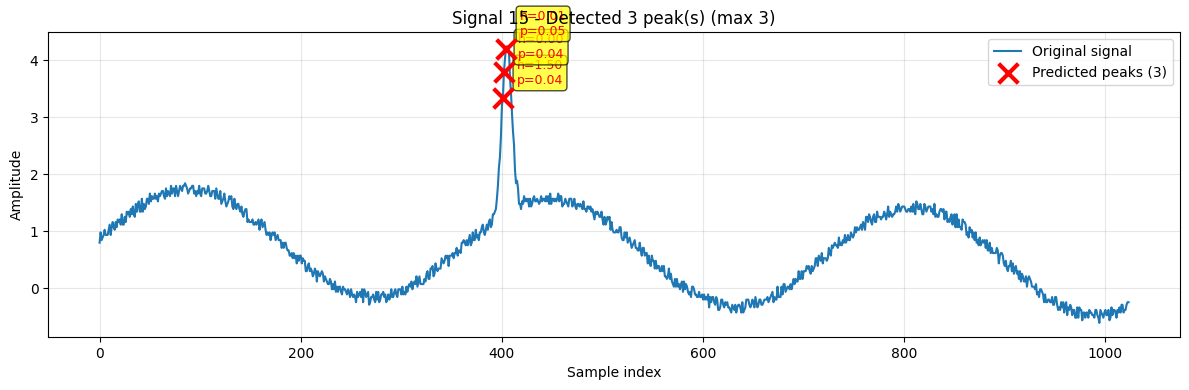

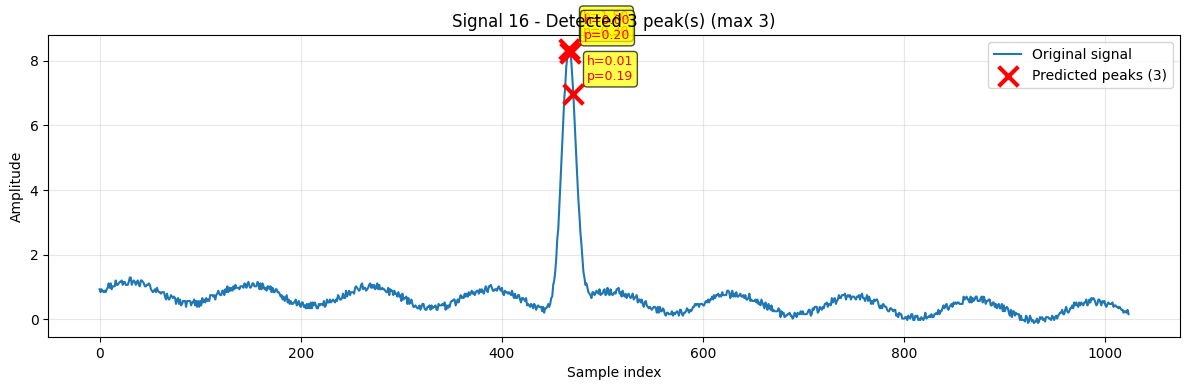

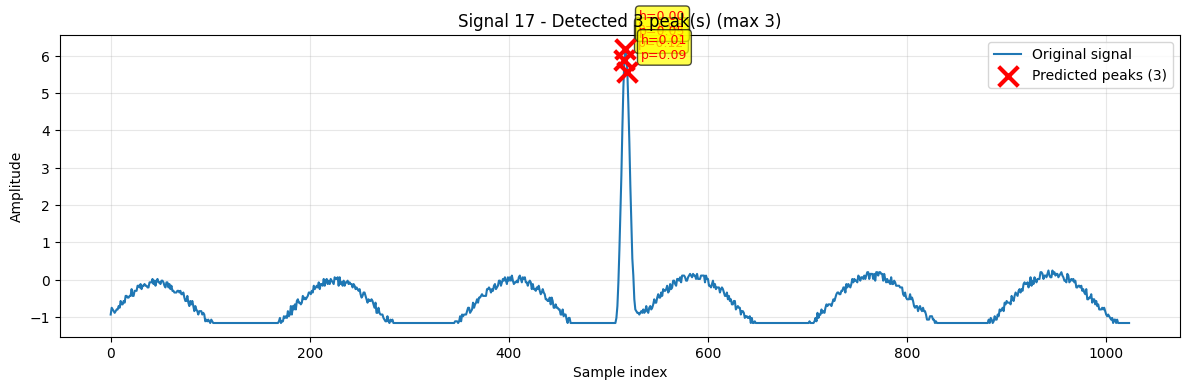

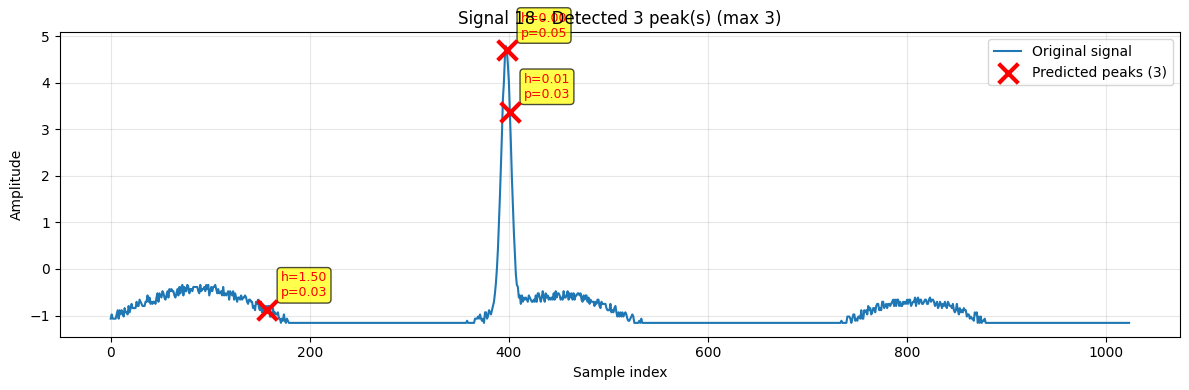

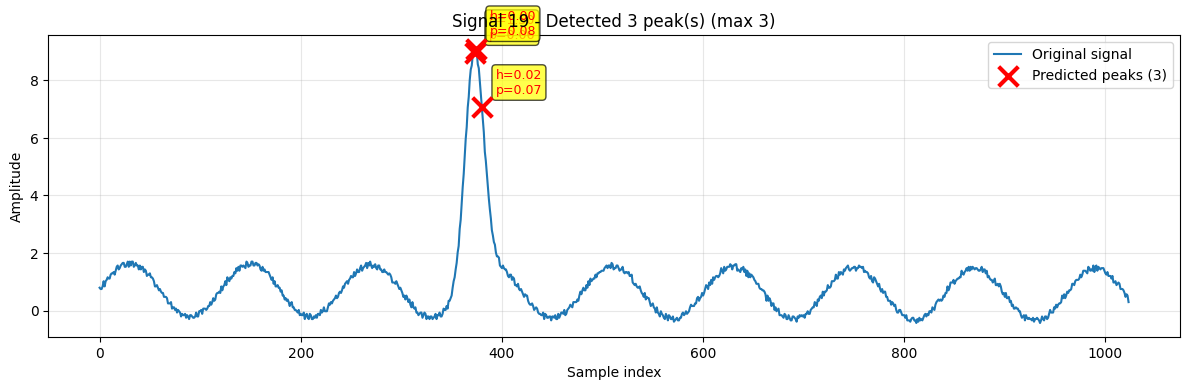

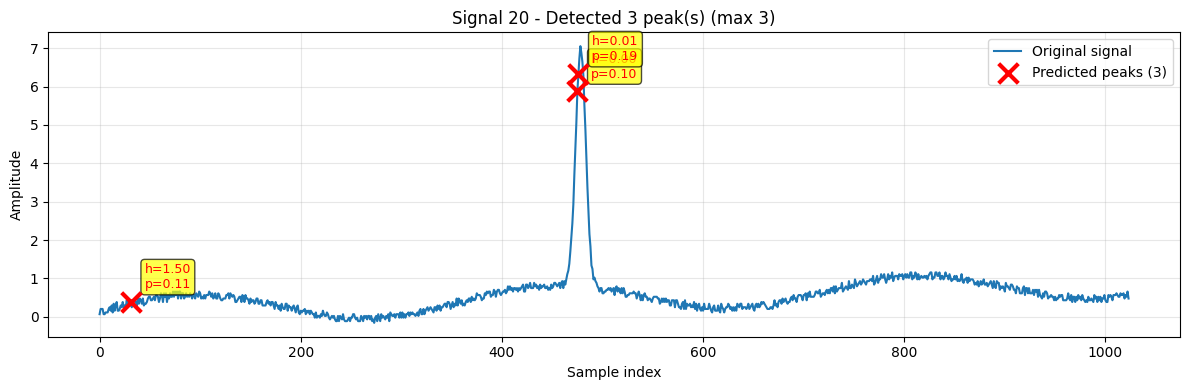

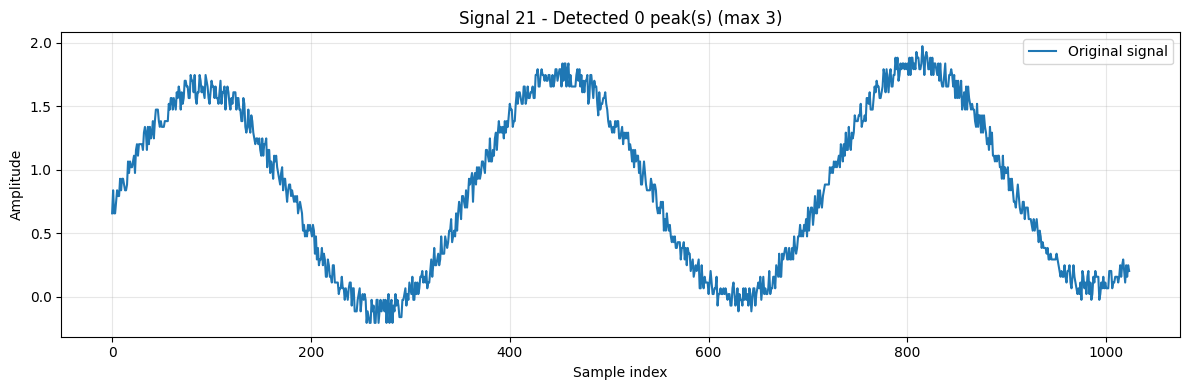

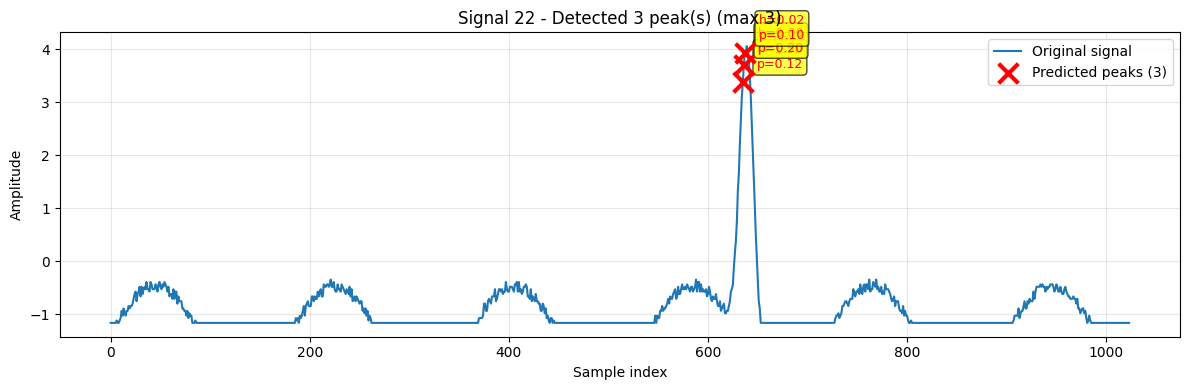

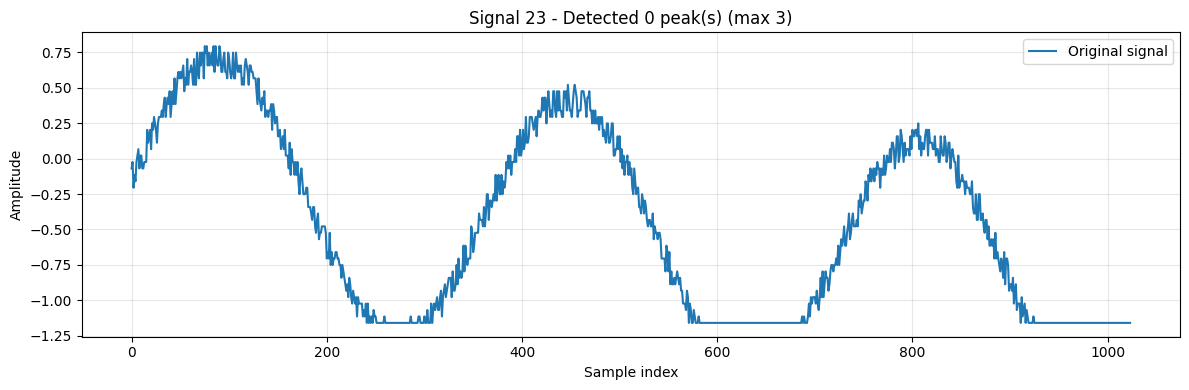

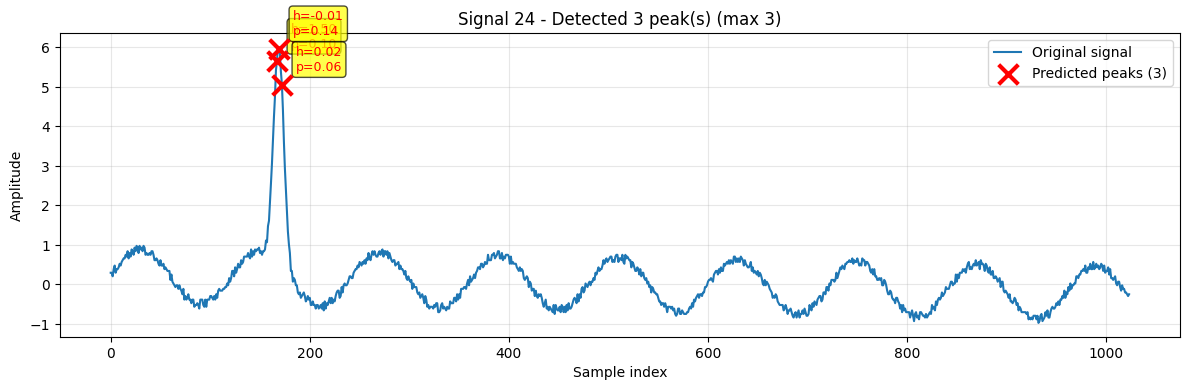

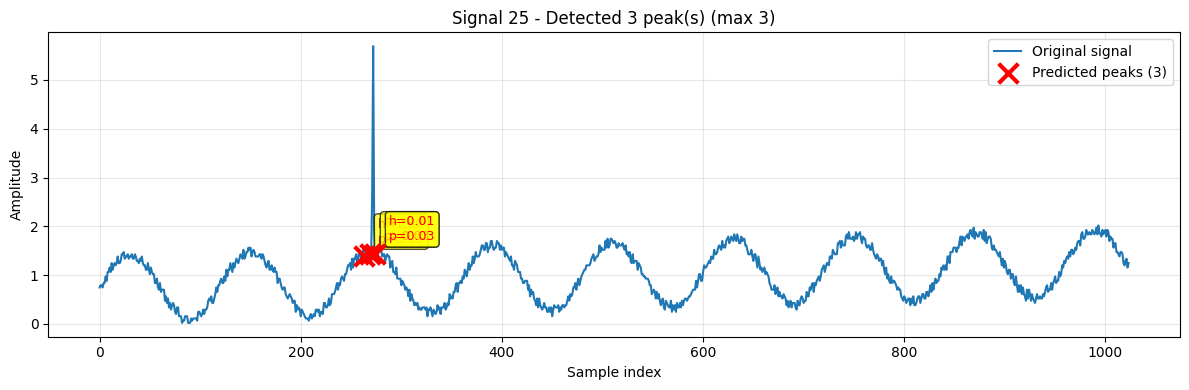

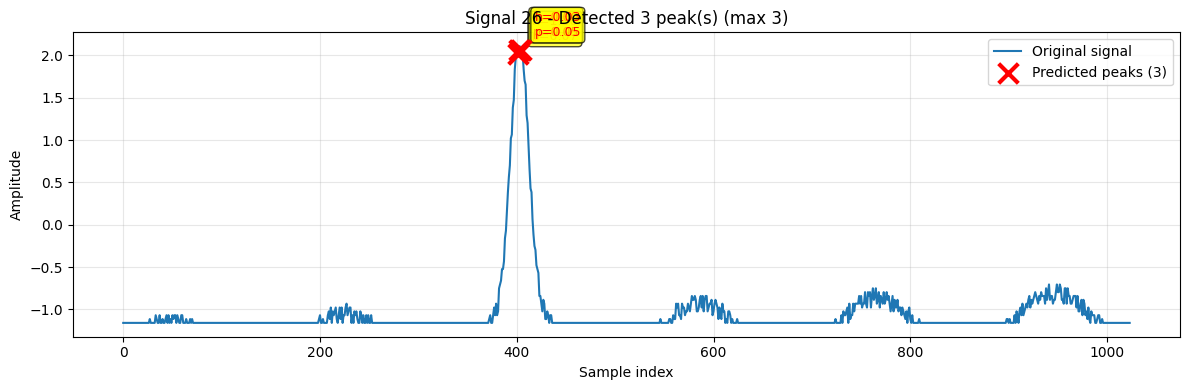

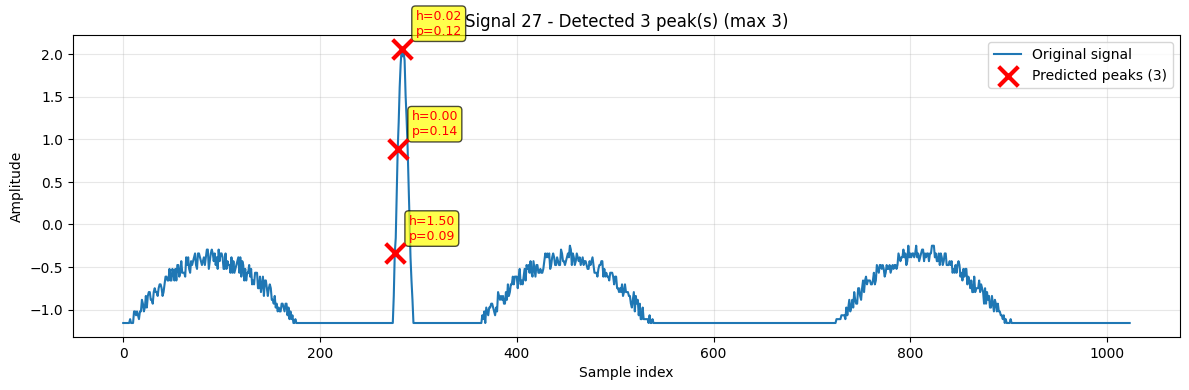

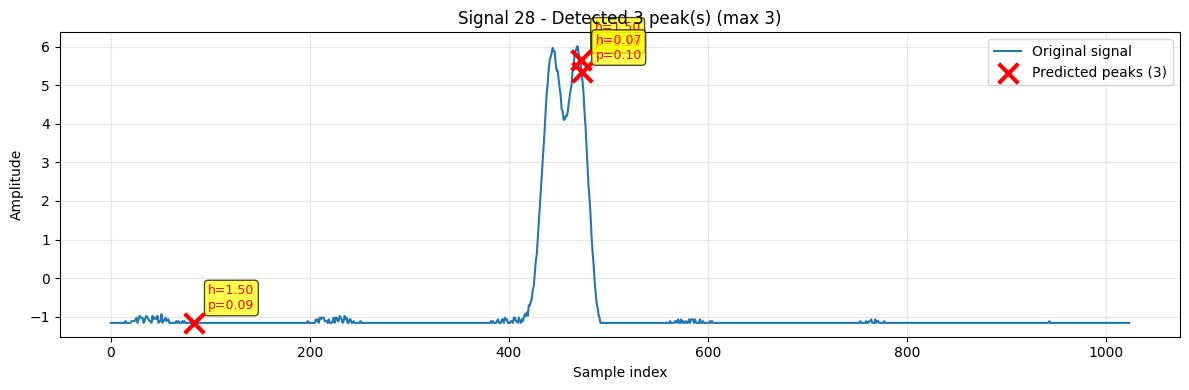

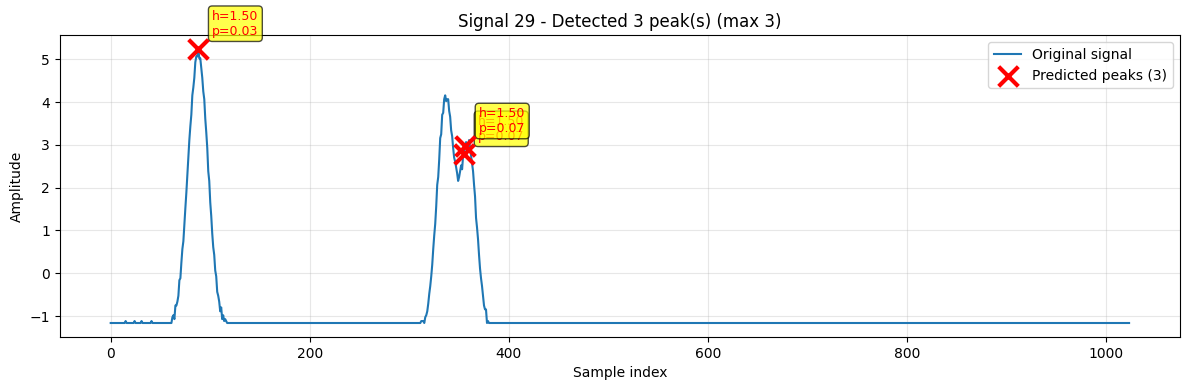

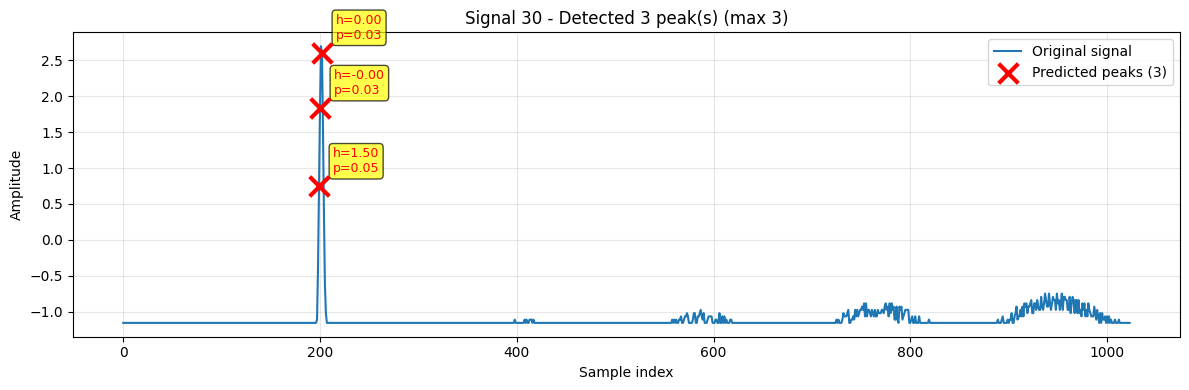

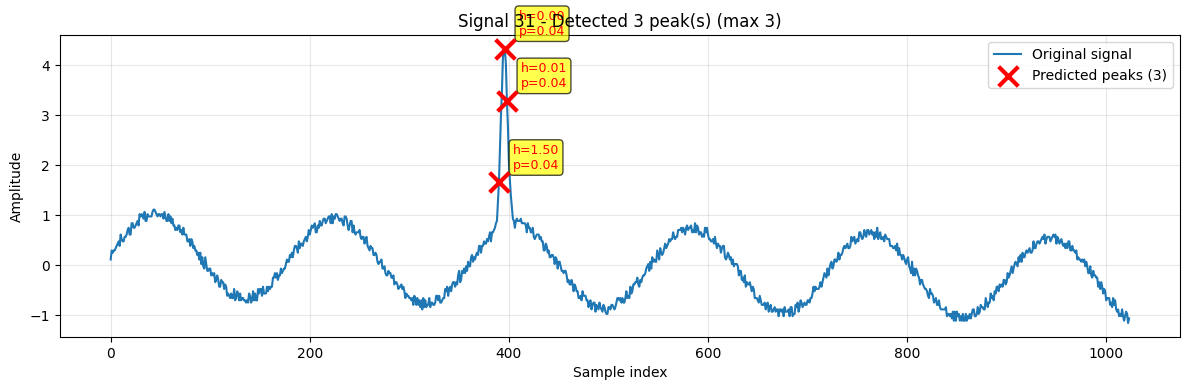

In [ ]:
# TOP 3 PEAKS
for i in range(min(50, signals.shape[0])): 
    signal_example = signals[i].cpu().numpy()
    positions_pred = pred_pos[i]    
    positions_pred = pred_pos[i]    
    heights_pred = pred_heights[i]    
    
    plt.figure(figsize=(7, 3))
    plt.plot(signal_example, label="Original signal", linewidth=1.5)
    
    threshold = 0.05
    peak_indices = np.where(positions_pred > threshold)[0]
    peak_probs = positions_pred[peak_indices]
    
    # Keep only top-3 peaks with highest probability
    if len(peak_indices) > 3:
        top_3_idx = np.argsort(peak_probs)[-3:]
        peak_indices = peak_indices[top_3_idx]
        peak_probs = peak_probs[top_3_idx]
    
    # Ordina per posizione per visualizzazione più chiara
    sort_idx = np.argsort(peak_indices)
    peak_indices = peak_indices[sort_idx]
    peak_probs = peak_probs[sort_idx]
    
    # Prendi solo le altezze corrispondenti ai picchi trovati
    num_peaks = len(peak_indices)
    peak_heights = heights_pred[:num_peaks]
    
    if num_peaks > 0:
        plt.scatter(peak_indices, signal_example[peak_indices], 
                   s=200, color='r', marker='x', linewidths=3,
                   label=f"Predicted peaks ({num_peaks})", zorder=5)
        
        # Annotate con height predictions e probabilities
        for idx, (pos, h, prob) in enumerate(zip(peak_indices, peak_heights, peak_probs)):
            plt.annotate(f'h={h:.2f}\np={prob:.2f}', 
                        xy=(pos, signal_example[pos]),
                        xytext=(10, 10), textcoords='offset points',
                        fontsize=9, color='red',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    plt.title(f"Signal {i} - Detected {num_peaks} peak(s) (max 3)")
    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

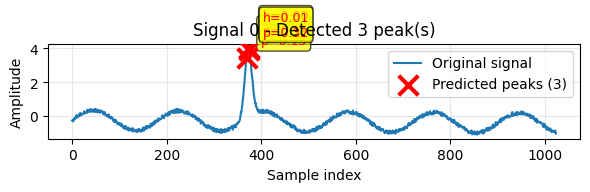

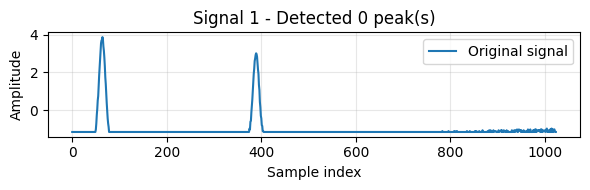

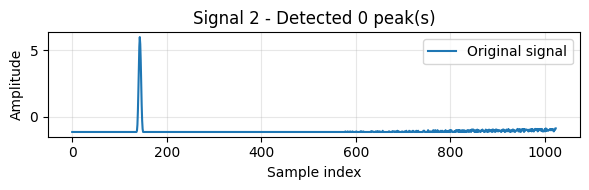

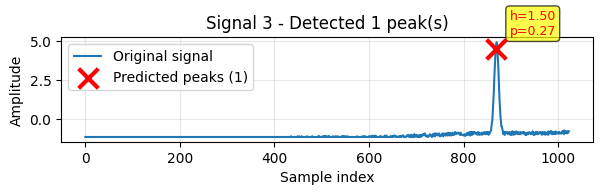

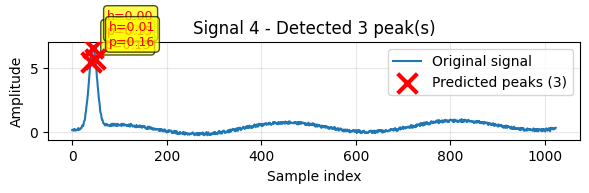

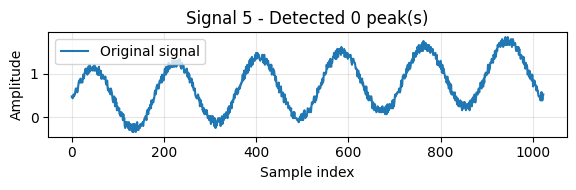

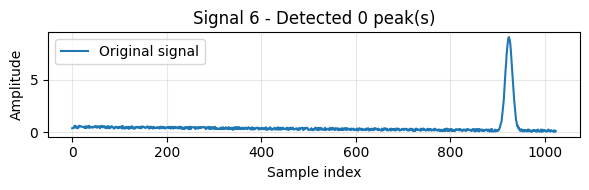

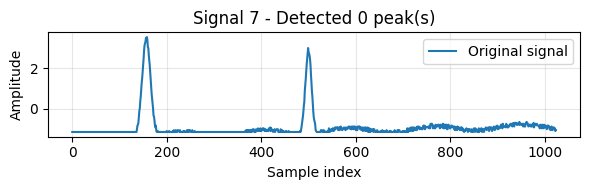

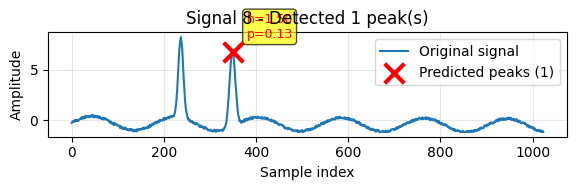

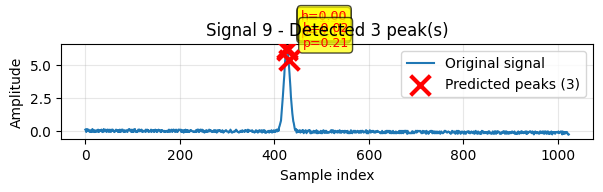

In [82]:
# TOP 3 PEACKS

for i in range(min(10, signals.shape[0])): 
    signal_example = signals[i].cpu().numpy()
    positions_pred = pred_pos[i]    
    heights_pred = pred_heights[i]    
    
    plt.figure(figsize=(6, 2))
    plt.plot(signal_example, label="Original signal", linewidth=1.5)
    
    if len(positions_pred) == len(signal_example):
        threshold = 0.1
        peak_indices = np.where(positions_pred > threshold)[0]
        peak_probs = positions_pred[peak_indices]
        
        # Keep only top-3 peaks with highest probability
        if len(peak_indices) > 3:
            top_3_idx = np.argsort(peak_probs)[-3:]
            peak_indices = peak_indices[top_3_idx]
            peak_probs = peak_probs[top_3_idx]
            peak_indices = np.sort(peak_indices)
    else:
        peak_indices = positions_pred
        peak_probs = np.ones(len(peak_indices))
    
    if len(peak_indices) > 0:
        plt.scatter(peak_indices, signal_example[peak_indices], 
                   s=200, color='r', marker='x', linewidths=3,
                   label=f"Predicted peaks ({len(peak_indices)})", zorder=5)
        
        # Annotate with height predictions and probabilities
        for idx, (pos, h) in enumerate(zip(peak_indices, heights_pred[:len(peak_indices)])):
            prob = peak_probs[idx] if idx < len(peak_probs) else 1.0
            plt.annotate(f'h={h:.2f}\np={prob:.2f}', 
                        xy=(pos, signal_example[pos]),
                        xytext=(10, 10), textcoords='offset points',
                        fontsize=9, color='red',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    plt.title(f"Signal {i} - Detected {len(peak_indices)} peak(s)")
    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

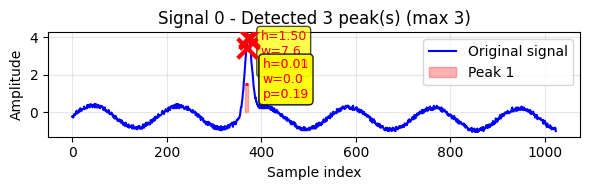

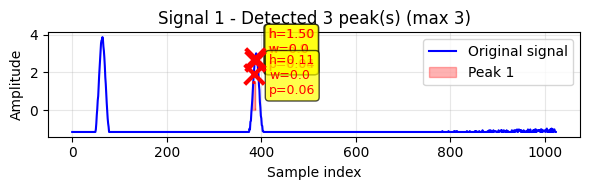

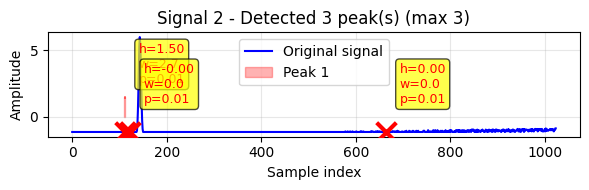

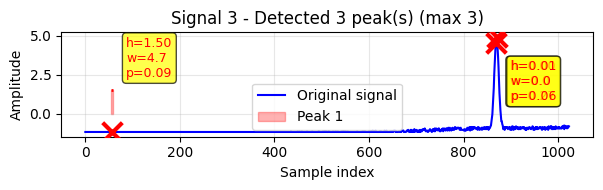

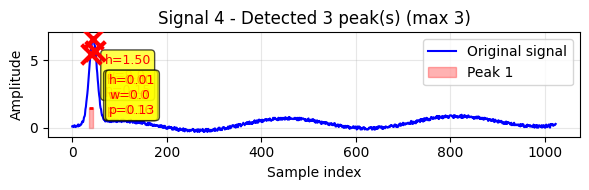

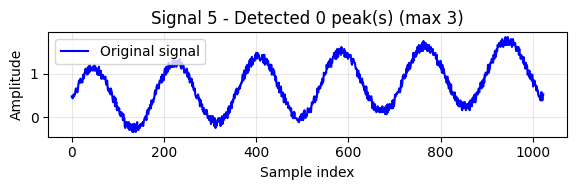

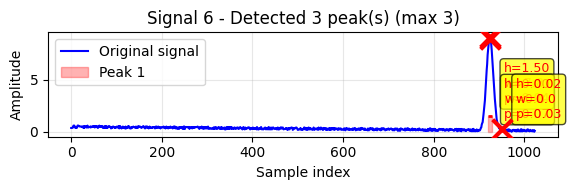

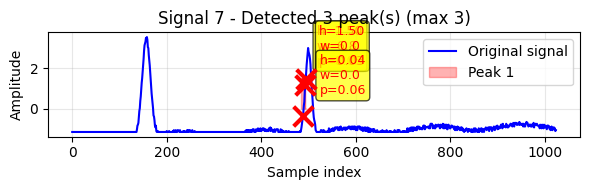

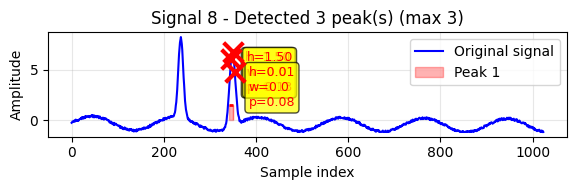

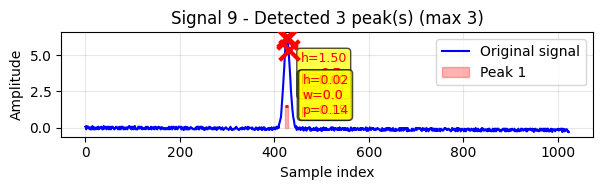

In [81]:
# TOP 3 PEAKS
for i in range(min(10, signals.shape[0])): 
    signal_example = signals[i].cpu().numpy()
    positions_pred = pred_pos[i]    
    heights_pred = pred_heights[i]
    widths_pred = pred_widths[i]
    
    plt.figure(figsize=(6, 2))
    plt.plot(signal_example, label="Original signal", linewidth=1.5, color='blue')
    
    threshold = 0.01
    peak_indices = np.where(positions_pred > threshold)[0]
    peak_probs = positions_pred[peak_indices]
    
    # Keep only top-3 peaks with highest probability
    if len(peak_indices) > 3:
        top_3_idx = np.argsort(peak_probs)[-3:]
        peak_indices = peak_indices[top_3_idx]
        peak_probs = peak_probs[top_3_idx]
    
    sort_idx = np.argsort(peak_indices)
    peak_indices = peak_indices[sort_idx]
    peak_probs = peak_probs[sort_idx]
    
    num_peaks = len(peak_indices)
    
    if num_peaks > 0:
        for idx in range(num_peaks):
            pos = peak_indices[idx]
            height = heights_pred[idx]
            width = widths_pred[idx]
            
            start = pos - width / 2
            stop = pos + width / 2
            
            plt.fill_between([start, stop], 0, height, 
                           alpha=0.3, color='red', 
                           label=f'Peak {idx+1}' if idx == 0 else "")
            
            plt.hlines(height, start, stop, colors='red', linewidth=2)
            
            plt.scatter([pos], [signal_example[int(pos)]], 
                       s=200, color='red', marker='x', linewidths=3, zorder=5)
            
            plt.annotate(f'h={height:.2f}\nw={width:.1f}\np={peak_probs[idx]:.2f}', 
                        xy=(pos, height),
                        xytext=(10, 10), textcoords='offset points',
                        fontsize=9, color='red',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    plt.title(f"Signal {i} - Detected {num_peaks} peak(s) (max 3)")
    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()